In [1]:
import os

from dotenv import load_dotenv

load_dotenv(os.path.join("..", ".env"), override=True)

%load_ext autoreload
%autoreload 2

## 上下文隔离：子代理

<img src="./resources/agent_header_subagent.png" width="800" style="display:block; margin-left:0;">

随着对话的进行，代理上下文会迅速增长，导致多个与长上下文相关的问题。一个主要问题是上下文冲突或混淆，即同一上下文窗口中的混合目标可能导致次优性能。[上下文隔离](https://blog.langchain.com/context-engineering-for-agents/)通过将任务委派给[专门的子代理](https://www.anthropic.com/engineering/multi-agent-research-system)提供了一个有效的解决方案，每个子代理都在其自己隔离的上下文窗口中运行。这种方法可以防止上下文冲突、混淆、污染和稀释，同时实现专注的、专业化的任务执行。



### 子代理委派
![./resources/subagents.png](./resources/subagents.png)

核心思路是我们可以创建具有针对不同任务定制的不同工具集的子代理。每个子代理都以 `subagent_type` 为键存储在注册表字典中，允许主代理通过 `task(description, subagent_type)` 工具调用委派工作。子代理与父代理的上下文完全隔离运行，其结果作为 `ToolMessage` 返回给父代理，保持清晰的关注点分离。


<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>注意：</b>  
<code>create_react_agent</code> 在 1.0 版本代码发布（拍摄后）已从 LangGraph 库移至 LangChain 库，并重命名为 <code>create_agent</code>。为此，导入和代码有细微调整。视频可能显示之前的配置。
</div>

**加载环境变量**：参考第一个模块中的 "环境配置" 部分。`dotenv` [文档](https://pypi.org/project/python-dotenv/) 会查找 `../.env` 文件。如果找到该文件，将从中加载环境变量，覆盖当前终端中的已有变量；如果未找到，则使用当前终端中的环境变量。

让我们定义用户将如何指定子代理
```python
from typing_extensions import TypedDict

class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str     ## used by main agent
    description: str  ## used by main agent
    prompt: str    # define sub agent
    tools: NotRequired[list[str]]   # define sub agent tools
```

我们将使用这些对象的列表来创建所有可用的子代理

```python
agents: list[SubAgent] = ...
subagents = {
    agent['name']: create_react_agent(
        model=model,
        prompt=agent['prompt'],
        tools = get_tools(agent['tools']),
        ...
    )
}
```

## Step 2: Create a tool to use Sub Agents

Logically, should look something like:

```python
def task(
    description: str  # 子代理应该执行的任务
    subagent_type: str  # 要使用的子代理类型
):
    # 创建新消息传递给子代理 - 应该只有描述
    # 调用子代理
    # 用子代理的响应以及文件系统的任何更改来更新状态
```

完整的代码如下：

```python
@tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
def task(
    description: str,
    subagent_type: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
):
    """将任务委托给具有隔离上下文的专门子代理。

    这为子代理创建了一个仅包含任务描述的全新上下文，
    防止父代理对话历史造成的上下文污染。
    """
    # 验证请求的代理类型是否存在
    if subagent_type not in agents:
        return f"Error: invoked agent of type {subagent_type}, the only allowed types are {[f'`{k}`' for k in agents]}"

    # 获取请求的子代理
    sub_agent = agents[subagent_type]

    # 创建仅包含任务描述的隔离上下文
    # 这是上下文隔离的关键 - 不包含父代理历史记录
    state["messages"] = [{"role": "user", "content": description}]

    # 在隔离环境中执行子代理
    result = sub_agent.invoke(state)

    # 通过 Command 状态更新将结果返回给父代理
    return Command(
        update={
            "files": result.get("files", {}),  # Merge any file changes
            "messages": [
                # Sub-agent result becomes a ToolMessage in parent context
                ToolMessage(
                    result["messages"][-1].content, tool_call_id=tool_call_id
                )
            ],
        }
    )

return task
```

In [4]:
%%writefile ../../src/deep_agents_from_scratch/task_tool.py
"""Task delegation tools for context isolation through sub-agents.

This module provides the core infrastructure for creating and managing sub-agents
with isolated contexts. Sub-agents prevent context clash by operating with clean
context windows containing only their specific task description.
"""

from typing import Annotated, NotRequired
from typing_extensions import TypedDict

from langchain_core.messages import ToolMessage
from langchain_core.tools import BaseTool, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState  # updated 1.0
from langchain.agents import create_agent  # updated 1.0

from langgraph.types import Command

from deep_agents_from_scratch.prompts import TASK_DESCRIPTION_PREFIX
from deep_agents_from_scratch.state import DeepAgentState


class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]


def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    """Create a task delegation tool that enables context isolation through sub-agents.

    This function implements the core pattern for spawning specialized sub-agents with
    isolated contexts, preventing context clash and confusion in complex multi-step tasks.

    Args:
        tools: List of available tools that can be assigned to sub-agents
        subagents: List of specialized sub-agent configurations
        model: The language model to use for all agents
        state_schema: The state schema (typically DeepAgentState)

    Returns:
        A 'task' tool that can delegate work to specialized sub-agents
    """
    # Create agent registry
    agents = {}

    # Build tool name mapping for selective tool assignment
    tools_by_name = {}
    for tool_ in tools:
        if not isinstance(tool_, BaseTool):
            tool_ = tool(tool_)
        tools_by_name[tool_.name] = tool_

    # Create specialized sub-agents based on configurations
    for _agent in subagents:
        if "tools" in _agent:
            # Use specific tools if specified
            _tools = [tools_by_name[t] for t in _agent["tools"]]
        else:
            # Default to all tools
            _tools = tools
        agents[_agent["name"]] = create_agent(   # updated 1.0
            model, system_prompt=_agent["prompt"], tools=_tools, state_schema=state_schema
        )

    # Generate description of available sub-agents for the tool description
    other_agents_string = [
        f"- {_agent['name']}: {_agent['description']}" for _agent in subagents
    ]

    @tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
    def task(
        description: str,
        subagent_type: str,
        state: Annotated[DeepAgentState, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        """Delegate a task to a specialized sub-agent with isolated context.

        This creates a fresh context for the sub-agent containing only the task description,
        preventing context pollution from the parent agent's conversation history.
        """
        # Validate requested agent type exists
        if subagent_type not in agents:
            return f"Error: invoked agent of type {subagent_type}, the only allowed types are {[f'`{k}`' for k in agents]}"

        # Get the requested sub-agent
        sub_agent = agents[subagent_type]

        # Create isolated context with only the task description
        # This is the key to context isolation - no parent history
        state["messages"] = [{"role": "user", "content": description}]

        # Execute the sub-agent in isolation
        result = sub_agent.invoke(state)

        # Return results to parent agent via Command state update
        return Command(
            update={
                "files": result.get("files", {}),  # Merge any file changes
                "messages": [
                    # Sub-agent result becomes a ToolMessage in parent context
                    ToolMessage(
                        result["messages"][-1].content, tool_call_id=tool_call_id
                    )
                ],
            }
        )

    return task

Overwriting ../../src/deep_agents_from_scratch/task_tool.py


现在，您有了一个可以将子代理生成为工具的例程。现在，您可以定义特定的子代理，并允许系统使用 `task` 工具调用它们。  
在上面，`_create_task_tool` 接收一个类型为 `SubAgent` 的列表。该列表包含要创建的代理的描述。

```python
class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]


def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    """Create a task delegation tool that enables context isolation through sub-agents.

```
`SubAgent` 类定义了满足子代理双重角色所需的独特信息。子代理既是工具也是代理。

- **作为工具**，它们为主管代理提供有关其能力以及如何调用它们的信息。
- **作为代理**，它们需要一个描述如何执行任务的提示词，以及一组针对这些任务的工具。

下面，您将创建一个研究子代理。它的 `description` 告知主管代理应将单个任务委托给此子代理。`SIMPLE_RESEARCH_INSTRUCTIONS` 是子代理用于指导其研究的提示词。在此示例中，它很简短，但对于通用研究者来说，它可以更加详细。子代理还配备了一个 `web_search` 工具，用于在其研究期间使用。
```python
# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}
```

请注意，子代理会接收一个特定的任务，以及完成该任务所需的工具。它在自己的上下文中运行，仅限于单个任务描述。这种[上下文工程](https://blog.langchain.com/context-engineering-for-agents/)方法确保子代理的工作上下文不会出现上下文冲突、混淆、污染或稀释。

主管代理的提示词现在必须包含如何调用和使用这些子代理的描述。如下所示。请注意*可用工具*的描述以及关于在适用情况下使用并行研究的说明。


In [5]:
from utils import show_prompt

from deep_agents_from_scratch.prompts import SUBAGENT_USAGE_INSTRUCTIONS

show_prompt(SUBAGENT_USAGE_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You can delegate tasks to sub-agents.                                                                          │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your role is to coordinate research by delegating specific research tasks to sub-agents.                       │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: Delegate research tasks to specialized sub-agents                     │
│     - description: Clear, specific research question or task                                                    │
│     - subagent_type: Type of agent to use (e.g., "research-agent")                                              │
│  2. **think_tool(reflection)**: Reflect on the results of each delegated task and plan next steps.              │
│     - reflection: Your detailed reflection on the results of the task and next steps.                           │
│                                                                                                                 │
│  **PARALLEL RESEARCH**: When you identify multiple independent research directions, make multiple **task**      │
│  tool calls in a single response to enable parallel execution. Use at most {max_concurrent_research_units}      │
│  parallel agents per iteration.                                                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Task Delegation Budgets** (Prevent excessive delegation):                                                    │
│  - **Bias towards focused research** - Use single agent for simple questions, multiple only when clearly        │
│  beneficial or when you have multiple independent research directions based on the user's request.              │
│  - **Stop when adequate** - Don't over-research; stop when you have sufficient information                      │
│  - **Limit iterations** - Stop after {max_researcher_iterations} task delegations if you haven't found          │
│  adequate sources                                                                                               │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│  <Scaling Rules>                                                                                                │
│  **Simple fact-finding, lists, and rankings** can use a single sub-agent:                                       │
│  - *Example*: "List the top 10 coffee shops in San Francisco" → Use 1 sub-agent, store in                       │
│  `findings_coffee_shops.md`                                                                                     │
│                                                                                                                 │
│  **Comparisons** can use a sub-agent for each element 

现在我们来构建一个带有监督者和子代理的研究系统。这只是一个模拟版本，使用预定义的搜索结果来演示各个部分如何组合在一起。在下一课中，你将构建一个完整的研究系统。


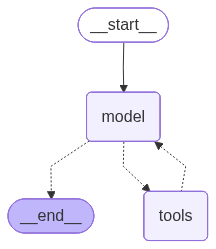

In [7]:
from datetime import datetime

from IPython.display import Image, display
import os
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent # updated in 1.0

from deep_agents_from_scratch.prompts import SUBAGENT_USAGE_INSTRUCTIONS
from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Mock search result
search_result = """模型上下文协议（MCP）是由Anthropic开发的开放标准协议，旨在实现AI模型与外部系统（如工具、数据库和其他服务）之间的无缝集成。它充当标准化的通信层，使AI模型能够以一致且高效的方式访问和利用来自各种来源的数据。本质上，MCP通过为数据交换提供统一的语言，简化了将AI助手连接到外部服务的过程。"""


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from the search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result


# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """你是一个研究员。研究提供给你的主题。重要提示：只需对web_search工具进行一次调用，并使用工具返回的结果来回答提供的主题。"""

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "将研究任务委托给子代理研究员。一次只给这位研究员一个主题。",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}

# Create agent using create_react_agent directly
# model = init_chat_model(
#     model="deepseek-chat",  
#     temperature=0.0,
# )
model = init_chat_model(
    model="agnes-2.0-flash",
    model_provider="openai",
    base_url=os.getenv("AGNES_BASE_URL"),
    api_key=os.getenv("AGNES_API_KEY"),
        temperature=0.0,
)
# Tools for sub-agent
sub_agent_tools = [web_search]

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

# Tools
delegation_tools = [task_tool]

# Create agent with system prompt
agent = create_agent(
    model,
    delegation_tools,
    system_prompt=SUBAGENT_USAGE_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
        date=datetime.now().strftime("%a %b %-d, %Y"),
    ),
    state_schema=DeepAgentState,
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [8]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "请给我一个关于MCP的概述。",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 请给我一个关于MCP的概述。                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "请提供关于MCP（Model Context                                                                  │
│ Protocol）的全面概述，包括：1）MCP是什么，由谁开发；2）MCP的主要功能和用途；3）MCP的架构和工作原理；4）MCP的优  │
│ 势和局限性；5）MCP在AI生态系统中的应用场景；6）MCP与其他类似协议（如OpenAPI、GraphQL等）的比较。请提供最新的信  │
│ 息。",                                                                                                          │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: chatcmpl-tool-b751491e11ea1f09                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ # MCP（Model Context Protocol）全面概述                                                                         │
│                                                                                                                 │
│ ## 1. MCP 是什么，由谁开发？                                                                                    │
│                                                                                                                 │
│ **MCP（Model Context Protocol，模型上下文协议）** 是由 **Anthropic**（Claude 大模型的开发商）于 2024 年 10      │
│ 月开源提出的一种**开放标准协议**。                                                                              │
│                                                                                                                 │
│ 其核心目标是解决 AI 模型（尤其是大型语言模型 LLM）与外部数据源、工具和服务之间连接碎片化的问题。MCP 旨在成为 AI │
│ 应用与外部世界通信的“USB-C 接口”——即一种通用、标准化的连接方式。                                                │
│                                                                                                                 │
│ ## 2. MCP 的主要功能和用途                                                                                      │
│                                                                                                                 │
│ MCP 的主要功能包括：                                                                                            │
│                                                                                                                 │
│ - **标准化连接**：为 AI 模型提供统一的方式访问外部数据（如数据库、文件系统、API、SaaS 服务等）。                │
│ - **工具调用（Tool Use）**：允许 AI 模型发现、调用并理解外部工具的功能和参数。                                  │
│ - **上下文注入**：将实时、动态的外部数据注入到 AI 模型的上下文中，增强其回答的准确性和相关性。                  │
│ - **资源访问**：使 AI 能够读取和写入外部资源（如文件、数据库记录等）。                                          │
│ - **提示工程辅助**：通过结构化方式提供系统提示、用户指令和上下文信息。                                          │
│                                                                                                                 │
│ **主要用途**：                                                                                                  │
│ - 构建 AI 助手，使其能访问企业内部数据。                                                                        │
│ - 开发 AI 驱动的应用程序，集成多种第三方服务。                                                                  │
│ - 实现 AI 模型与本地或云端资源的无缝交互。                                                                      │
│                                                                                                                 │
│ ## 3. MCP 的架构和工作原理                                                                                      │
│                                                                                                                 │
│ MCP 采用**客户端-服务器（Client-Server）**架构，基于**JSON-RPC 2.0** 协议进行通信。                             │
│                                                                                                                 │
│ ### 核心组件：                                                                                                  │
│ 1. **MCP Host（主机）**：运行 AI 模型的应用程序（如 Claude Desktop、Cursor、VS Code 等）。                      │
│ 2. **MCP Client（客户端）**：嵌入在主机中，负责与服务器通信。                                                   │
│ 3. **MCP Server（服务器）**：提供特定数据源或工具的服务端程序。                                                 │
│                                                                                                                 │
│ ### 工作原理：                                                                                                  │
│ 1. **发现（Discovery）**：客户端向服务器发送请求，获取其提供的工具、资源和提示模板列表。                        │
│ 2. **调用（Invocation）**：AI 模型根据用户需求，通过客户端向服务器发送工具调用请求。                            │
│ 3. **执行（Execution）**：服务器执行相应操作（如查询数据库、读取文件），并将结果返回给客户端。                  │
│ 4. **响应（Response）**：客户端将结果传递给 AI 模型，模型据此生成最终回答。                  

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ## MCP（Model Context Protocol）概述                                                                            │
│                                                                                                                 │
│ **MCP（Model Context Protocol，模型上下文协议）** 是由 **Anthropic**（Claude 大模型的开发商）于 2024 年 10      │
│ 月开源提出的一种**开放标准协议**。                                                                              │
│                                                                                                                 │
│ ### 核心定位                                                                                                    │
│ MCP 旨在解决 AI 模型（尤其是大型语言模型 LLM）与外部数据源、工具和服务之间连接碎片化的问题。它被比喻为 AI       │
│ 应用与外部世界通信的 **"USB-C 接口"**——一种通用、标准化的连接方式。                                             │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 主要功能                                                                                                    │
│ - **标准化连接**：为 AI 模型提供统一方式访问外部数据（数据库、文件系统、API、SaaS 服务等）                      │
│ - **工具调用**：允许 AI 模型发现、调用并理解外部工具的功能和参数                                                │
│ - **上下文注入**：将实时、动态的外部数据注入 AI 模型的上下文中，增强回答的准确性                                │
│ - **资源访问**：使 AI 能够读取和写入外部资源（如文件、数据库记录等）                                            │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 架构和工作原理                                                                                              │
│ MCP 采用**客户端-服务器架构**，基于 **JSON-RPC 2.0** 协议通信：                                                 │
│                                                                                                                 │
│ 1. **MCP Host（主机）**：运行 AI 模型的应用程序（如 Claude Desktop、Cursor、VS Code 等）                        │
│ 2. **MCP Client（客户端）**：嵌入在主机中，负责与服务器通信                                                     │
│ 3. **MCP Server（服务器）**：提供特定数据源或工具的服务端程序                                                   │
│                                                                                                                 │
│ **工作流程**：发现 → 调用 → 执行 → 响应                                                                         │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 优势与局限性                                                                                                │
│                                                                                                                 │
│ **优势**：                                                                                                      │
│ - 标准化，消除碎片化，降低集成成本                                                                              │
│ - 灵活扩展，支持多种数据源和工具类型                                                                            │
│ - 开源与社区驱动                                                                                                │
│ - 支持实时数据访问                                                                                              │

### Streaming Agent Execution

Stream the agent to see sub-agent delegation in real-time:



In [9]:
from utils import stream_agent
import asyncio

# This shows sub-agent calls with graph/node names
await stream_agent(
    agent,
    {"messages": [{"role": "user", "content": "请给我一个关于MCP的概述。"}]},
)

Graph: root
Node: model


╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "请提供关于MCP（Model Context                                                                  │
│ Protocol）的详细概述，包括其定义、主要功能、应用场景以及它如何帮助AI模型更好地与外部数据和工具集成。",          │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: chatcmpl-tool-9108338fb1bedf40                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Graph: ('tools:072cb423-e150-faf2-9938-d24e217a3c8c',)
Node: model


╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "MCP Model Context Protocol definition features use cases AI integration"                            │
│ }                                                                                                               │
│    ID: chatcmpl-tool-bc1a00d43710d88d                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Graph: ('tools:072cb423-e150-faf2-9938-d24e217a3c8c',)
Node: tools


...

Graph: root
Node: tools


╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 以下是关于 **MCP（Model Context Protocol，模型上下文协议）** 的详细概述：                                       │
│                                                                                                                 │
│ ### 1. 定义                                                                                                     │
│ **MCP（Model Context Protocol）** 是由 Anthropic                                                                │
│ 开发的一种开放标准协议。它的核心目标是解决大语言模型（LLM）与外部数据源、工具及服务之间连接碎片化的问题。       │
│                                                                                                                 │
│ 你可以将 MCP 想象为 AI 领域的 **USB-C 接口** 或 **PCIe 总线**。在 USB-C                                         │
│ 出现之前，不同的设备需要不同的专用线缆；而在 PCIe 出现之前，显卡、网卡等扩展卡需要各自独立的通信标准。同样，MCP │
│ 旨在为 AI 模型提供一个统一的、标准化的方式来连接和交互外部世界，无论底层数据源是本地文件、数据库还是远程 API。  │
│                                                                                                                 │
│ ### 2. 主要功能                                                                                                 │
│ MCP 协议主要具备以下关键功能：                                                                                  │
│                                                                                                                 │
│ *   **标准化连接**：它定义了一套通用的通信规范，使得 AI 应用（Host）可以无需编写特定代码即可与任何支持 MCP      │
│ 的工具或数据源（Client/Server）进行对话。                                                                       │
│ *   **资源发现与访问**：AI 模型可以通过 MCP 动态发现可用的数据资源（如文件系统、数据库表、API                   │
│ 端点），并读取这些资源的内容作为上下文。                                                                        │
│ *   **工具调用（Tool Use）**：允许 AI                                                                           │
│ 模型执行外部操作，例如运行代码、查询数据库、发送电子邮件或控制智能家居设备。MCP                                 │
│ 定义了工具的描述、参数和执行结果的标准格式。                                                                    │
│ *   **提示词模板共享**：支持预定义的提示词模板，确保 AI 在与特定任务交互时使用一致的指令结构。                  │
│ *   **双向通信**：不仅 AI 可以向外部请求数据，外部系统也可以向 AI 推送通知或更新，实现更实时的交互。            │
│                                                                                                                 │
│ ### 3. 应用场景                                                                                                 │
│ MCP 的应用场景非常广泛，涵盖了从个人助理到企业级自动化等多个领域：                                              │
│                                                                                                                 │
│ *   **开发者工具集成**：                                                                                        │
│     *   IDE（如 VS Code）中的 AI 助手可以直接通过 MCP 访问项目代码库、Git                                       │
│ 历史、终端输出和调试器状态，从而提供更精准的代码补全和错误修复建议。                                            │
│ *   **企业数据智能**：                                                                                          │
│     *   员工可以通过自然语言查询内部数据库、CRM 系统（如 Salesforce）、ERP 系统或文档存储（如                   │
│ Notion、Confluence），MCP 负责将这些异构数据源标准化地暴露给 AI。                                               │
│ *   **个人生产力助手**：                                                                                        │
│     *   AI 助手可以连接用户的日历、邮件客户端、笔记应用和本地文件系统，帮助用户安排会议、总结邮件或整理笔记。   │
│ *   **IoT 与智能家居**：                                                                                        │
│     *   通过 MCP，AI 可以安全地控制智能家居设备（如灯光、恒温器），而无需为每个品牌开发单独的插件。             │
│ *   **研究与分析**：                                                                                            │
│     *   研究人员可以利用 MCP 连接学术数据库、实验仪器数据流或科学计算工具，加速数据分析过程。                   │
│                                                                                                                 │
│ ### 4. 如何帮助 AI 模型更好地与外部数据和工具集成？                                                             │
│                                                      

Graph: root
Node: model


╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 好的，这是关于 **MCP（Model Context Protocol，模型上下文协议）** 的概述：                                       │
│                                                                                                                 │
│ ### 1. 定义                                                                                                     │
│ **MCP（Model Context Protocol）** 是由 Anthropic                                                                │
│ 开发的一种开放标准协议。它的核心目标是解决大语言模型（LLM）与外部数据源、工具及服务之间连接碎片化的问题。       │
│                                                                                                                 │
│ 你可以将 MCP 想象为 AI 领域的 **USB-C 接口** 或 **PCIe 总线**。在 USB-C                                         │
│ 出现之前，不同的设备需要不同的专用线缆；而在 PCIe 出现之前，显卡、网卡等扩展卡需要各自独立的通信标准。同样，MCP │
│ 旨在为 AI 模型提供一个统一的、标准化的方式来连接和交互外部世界，无论底层数据源是本地文件、数据库还是远程 API。  │
│                                                                                                                 │
│ ### 2. 主要功能                                                                                                 │
│ MCP 协议主要具备以下关键功能：                                                                                  │
│                                                                                                                 │
│ *   **标准化连接**：它定义了一套通用的通信规范，使得 AI 应用（Host）可以无需编写特定代码即可与任何支持 MCP      │
│ 的工具或数据源（Client/Server）进行对话。                                                                       │
│ *   **资源发现与访问**：AI 模型可以通过 MCP 动态发现可用的数据资源（如文件系统、数据库表、API                   │
│ 端点），并读取这些资源的内容作为上下文。                                                                        │
│ *   **工具调用（Tool Use）**：允许 AI                                                                           │
│ 模型执行外部操作，例如运行代码、查询数据库、发送电子邮件或控制智能家居设备。MCP                                 │
│ 定义了工具的描述、参数和执行结果的标准格式。                                                                    │
│ *   **提示词模板共享**：支持预定义的提示词模板，确保 AI 在与特定任务交互时使用一致的指令结构。                  │
│ *   **双向通信**：不仅 AI 可以向外部请求数据，外部系统也可以向 AI 推送通知或更新，实现更实时的交互。            │
│                                                                                                                 │
│ ### 3. 应用场景                                                                                                 │
│ MCP 的应用场景非常广泛，涵盖了从个人助理到企业级自动化等多个领域：                                              │
│                                                                                                                 │
│ *   **开发者工具集成**：                                                                                        │
│     *   IDE（如 VS Code）中的 AI 助手可以直接通过 MCP 访问项目代码库、Git                                       │
│ 历史、终端输出和调试器状态，从而提供更精准的代码补全和错误修复建议。                                            │
│ *   **企业数据智能**：                                                                                          │
│     *   员工可以通过自然语言查询内部数据库、CRM 系统（如 Salesforce）、ERP 系统或文档存储（如                   │
│ Notion、Confluence），MCP 负责将这些异构数据源标准化地暴露给 AI。                                               │
│ *   **个人生产力助手**：                                                                                        │
│     *   AI 助手可以连接用户的日历、邮件客户端、笔记应用和本地文件系统，帮助用户安排会议、总结邮件或整理笔记。   │
│ *   **IoT 与智能家居**：                                                                                        │
│     *   通过 MCP，AI 可以安全地控制智能家居设备（如灯光、恒温器），而无需为每个品牌开发单独的插件。             │
│ *   **研究与分析**：                                                                                            │
│     *   研究人员可以利用 MCP 连接学术数据库、实验仪器数据流或科学计算工具，加速数据分析过程。                   │
│                                                                                                                 │
│ ### 4. 如何帮助 AI 模型更好地与外部数据和工具集成？                                                             │
│                                                      

{'messages': [HumanMessage(content='请给我一个关于MCP的概述。', additional_kwargs={}, response_metadata={}, id='5aba954f-f4ba-402d-afa2-a652e609dcb5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 1057, 'total_tokens': 1130, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'agnes-2.0-flash', 'system_fingerprint': 'vllm-0.21.0-tp2-52bef988', 'id': 'chatcmpl-a26cf3ebfca3bf45', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ebc6b-8918-7193-9bb3-f7ca4a4cc9cf-0', tool_calls=[{'name': 'task', 'args': {'description': '请提供关于MCP（Model Context Protocol）的详细概述，包括其定义、主要功能、应用场景以及它如何帮助AI模型更好地与外部数据和工具集成。', 'subagent_type': 'research-agent'}, 'id': 'chatcmpl-tool-9108338fb1bedf40', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1057, 'output_tokens': 73, 'total_tokens': 1130, 'input_token_details': {}, 'output_toke

Trace: 
https://smith.langchain.com/public/26cc1c2b-e785-4c6d-a2a7-c30a31875fc7/r
<!-- https://smith.langchain.com/public/edc4e672-db9c-457a-953d-f62e7813591c/r -->